# __Financial Fraud Detection Analysis: Anomaly Detection in Credit Card Transactions__ 

#### __by Nehir Bağır Budan__

## __Introduction & Methodology__

This analysis uses Python for Exploratory Data Analysis (EDA) on credit card transaction data to identify patterns related to fraud.

The process includes data inspection, handling missing values, analyzing distributions, and examining relationships between variables. Key comparisons are made between fraud (is_fraud) and non-fraud transactions.

Findings are also cross-checked with previous SQL and Excel analyses to ensure consistency.

### __1. Exploratory Data Analysis (EDA) with Python:__

In [1]:
# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Interactive Visualization ---
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import HoverTool

# Activate Bokeh in notebook
output_notebook()

# --- Display Settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Style ---
sns.set(style="whitegrid")

# --- Load Datasets ---
cc_df = pd.read_csv('cc_data.csv')
loc_df = pd.read_csv('location_data.csv')

# --- Quick Preview ---
print("cc_data preview:")
display(cc_df.head())

print("\nlocation_data preview:")
display(loc_df.head())

Loading BokehJS ...

cc_data preview:


,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,23-03-2019 03:06,3586008444788260,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,Issaquah,WA,98027,47.50,-122.01,50489,Osteopath,29-02-1984,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.35,-121.64,0
1,1185025,10-05-2020 11:28,4671727014157740,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,Andrews,IN,46702,40.86,-85.61,2304,Retail banker,25-07-1955,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.27,-85.91,0
2,10818,07-01-2019 13:31,377993105397617,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,Oconto Falls,WI,54154,44.88,-88.16,5548,Mining engineer,11-09-1975,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.51,-88.69,0
3,975275,30-01-2020 18:49,4710826438164840000,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,Turner,MT,59542,48.83,-108.40,192,Further education lecturer,04-01-1964,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.91,-109.01,0
4,346814,12-06-2019 03:04,372382441451095,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,Port Ewen,NY,12466,41.89,-73.98,2471,Heritage manager,21-01-1966,8e1306b47052ac10fe48512de79edf71,1339470288,41.53,-74.45,0



location_data preview:


,cc_num,lat,long
0,3586010000000000.00,47.50,-122.01
1,4671730000000000.00,40.86,-85.61
2,377993000000000.00,44.88,-88.16
3,4710830000000000000.00,48.83,-108.40
4,372382000000000.00,41.89,-73.98


#__1. The dimensions (number of rows and columns) of the dataset__

In [2]:
# cc_data dimensions
rows, cols = cc_df.shape
print(f"cc_data contains {rows} rows and {cols} columns.")

# location_data dimensions
rows_loc, cols_loc = loc_df.shape
print(f"location_data contains {rows_loc} rows and {cols_loc} columns.")

cc_data contains 389002 rows and 23 columns.
location_data contains 979 rows and 3 columns.


### __2. Unique values in each categorical variable__

In [3]:
# Select categorical columns
categorical_cols = cc_df.select_dtypes(include=['object']).columns

# Count unique values for each categorical column
unique_counts = cc_df[categorical_cols].nunique()

# Display results
unique_counts_df = unique_counts.reset_index()
unique_counts_df.columns = ['Column', 'Unique Values']

# Sort
unique_counts_df = unique_counts_df.sort_values(by='Unique Values', ascending=False)

unique_counts_df

,Column,Unique Values
11,trans_num,389002
0,trans_date_trans_time,293627
6,street,979
10,dob,964
7,city,890
1,merchant,693
9,job,492
4,last,481
3,first,352
8,state,51


### __3. The distribution of numerical variables in the dataset__

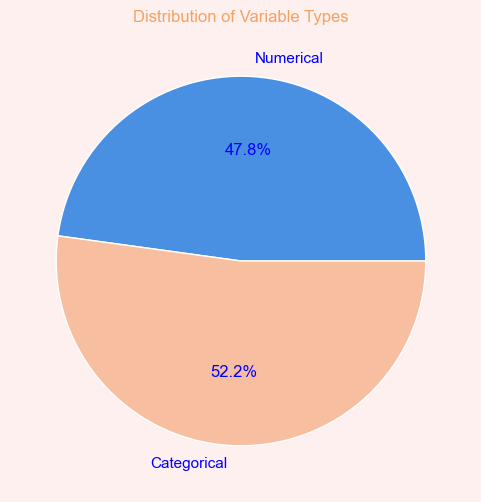

In [4]:
# Numerical columns
num_cols = cc_df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = cc_df.select_dtypes(include=['object']).columns

# Create summary
summary_df = pd.DataFrame({
    'Type': ['Numerical', 'Categorical'],
    'Count': [len(num_cols), len(cat_cols)]
})

# Add percentage
summary_df['Percentage (%)'] = (summary_df['Count'] / cc_df.shape[1]) * 100

summary_df

plt.figure(figsize=(6,6))

# Dark background
plt.gcf().patch.set_facecolor("#fff0f0")

# Pie chart
plt.pie(
    summary_df['Count'],
    labels=summary_df['Type'],
    autopct='%1.1f%%',
    colors=['#4A90E2', "#F7BF9F"],  # blue & orange
    textprops={'color': 'blue'}
)

# Title styling
plt.title('Distribution of Variable Types', color='#F4A261')

plt.show()


### __4. The Missing Values in the Dataset__

In [5]:
# Total missing values
total_missing = cc_df.isnull().sum().sum()
print(f"Total missing values in dataset: {total_missing}")

# Total missing values
total_missing_loc = loc_df.isnull().sum().sum()
print(f"Total missing values in dataset: {total_missing}")

Total missing values in dataset: 0
Total missing values in dataset: 0


### __5. The summary statistics (mean, median, min, max, etc.) for numerical variables.__

In [6]:
# Select key variables
key_cols = ['amt', 'city_pop']

# Summary stats
summary_stats = cc_df[key_cols].describe().T

# Add median
summary_stats['median'] = cc_df[key_cols].median()

# Round values
summary_stats = summary_stats.round(2)

summary_stats

summary_stats.style.background_gradient(cmap='Blues').format("{:.2f}")


,count,mean,std,min,25%,50%,75%,max,median
amt,389002.00,70.44,162.20,1.00,9.66,47.57,83.08,27390.12,47.57
city_pop,389002.00,88680.84,301210.10,23.00,743.00,2456.00,20328.00,2906700.00,2456.00


### __6. Correlation between numerical variables__

In [7]:
# --- Prepare datetime ---
cc_df['trans_date_trans_time'] = pd.to_datetime(cc_df['trans_date_trans_time'])
cc_df['dob'] = pd.to_datetime(cc_df['dob'])

# --- Create age ---
cc_df['age'] = (cc_df['trans_date_trans_time'] - cc_df['dob']).dt.days // 365


# --- Correlations ---
age_corr = cc_df[['age', 'is_fraud']].corr().iloc[0,1]
amt_corr = cc_df[['amt', 'is_fraud']].corr().iloc[0,1]
city_corr = cc_df[['amt', 'city_pop']].corr().iloc[0,1]

# --- Categorical Fraud Rates ---
top_category = cc_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(1)
top_job = cc_df.groupby('job')['is_fraud'].mean().sort_values(ascending=False).head(1)

# --- Build Summary Table ---
summary_table = pd.DataFrame({
    'Analysis': [
        'Age vs Fraud',
        'Amount vs Fraud',
        'Amount vs City Population',
        'Top Fraud Category',
        'Top Fraud Job'
    ],
    'Result': [
        round(age_corr, 4),
        round(amt_corr, 4),
        round(city_corr, 4),
        f"{top_category.index[0]} ({top_category.values[0]:.4f})",
        f"{top_job.index[0]} ({top_job.values[0]:.4f})"
    ]
})

summary_table

C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\3974291994.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cc_df['trans_date_trans_time'] = pd.to_datetime(cc_df['trans_date_trans_time'])
C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\3974291994.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cc_df['dob'] = pd.to_datetime(cc_df['dob'])


,Analysis,Result
0,Age vs Fraud,0.01
1,Amount vs Fraud,0.21
2,Amount vs City Population,0.01
3,Top Fraud Category,shopping_net (0.0163)
4,Top Fraud Job,Forest/woodland manager (1.0000)


### __7. The distribution of an amt differ across is_fraud categories__

C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\2190988659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


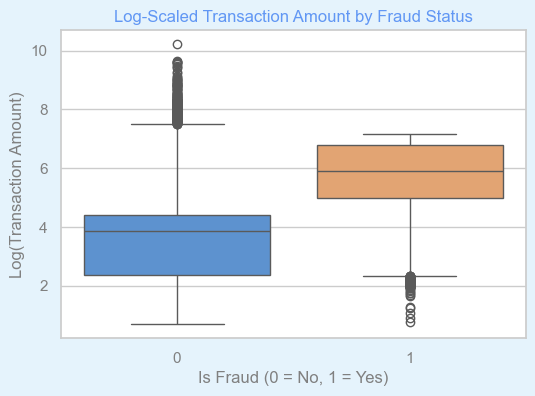

In [8]:
plt.figure(figsize=(6,4))

plt.gcf().patch.set_facecolor("#e5f3fc")

sns.boxplot(
    x='is_fraud',
    y=np.log1p(cc_df['amt']),  # 🔥 log transform
    data=cc_df,
    palette=['#4A90E2', '#F4A261']
)

plt.title('Log-Scaled Transaction Amount by Fraud Status', color="#6197F4")
plt.xlabel('Is Fraud (0 = No, 1 = Yes)', color='gray')
plt.ylabel('Log(Transaction Amount)', color='gray')
plt.xticks(color='gray')
plt.yticks(color='gray')

plt.show()



### __8. Outliers in city_pop and amt__

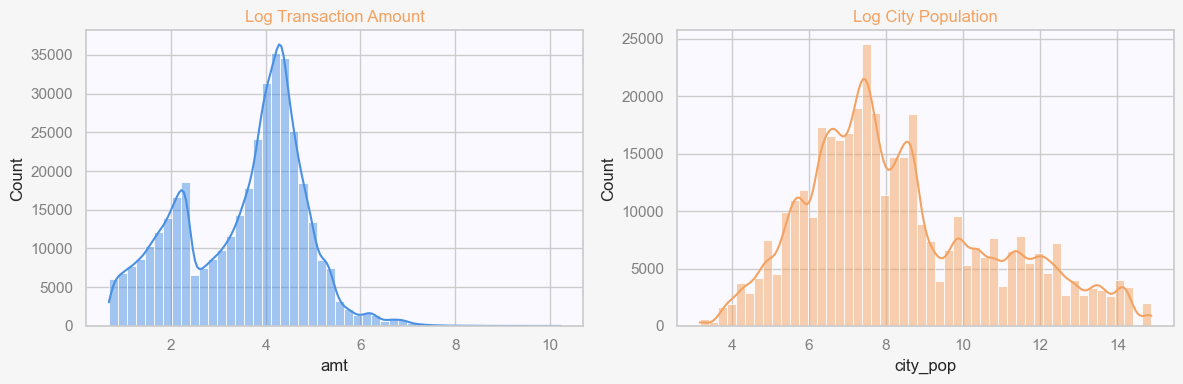

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
fig.patch.set_facecolor("#f6f6f6")

# amt
sns.histplot(np.log1p(cc_df['amt']), bins=50, kde=True,
             color='#4A90E2', ax=axes[0])
axes[0].set_title('Log Transaction Amount', color='#F4A261')
axes[0].set_facecolor("#f9f9ff")
axes[0].tick_params(colors='gray')

# city_pop
sns.histplot(np.log1p(cc_df['city_pop']), bins=50, kde=True,
             color='#F4A261', ax=axes[1])
axes[1].set_title('Log City Population', color='#F4A261')
axes[1].set_facecolor('#f9f9ff')
axes[1].tick_params(colors='gray')

plt.tight_layout()
plt.show()

### __9. Trends Over Time__

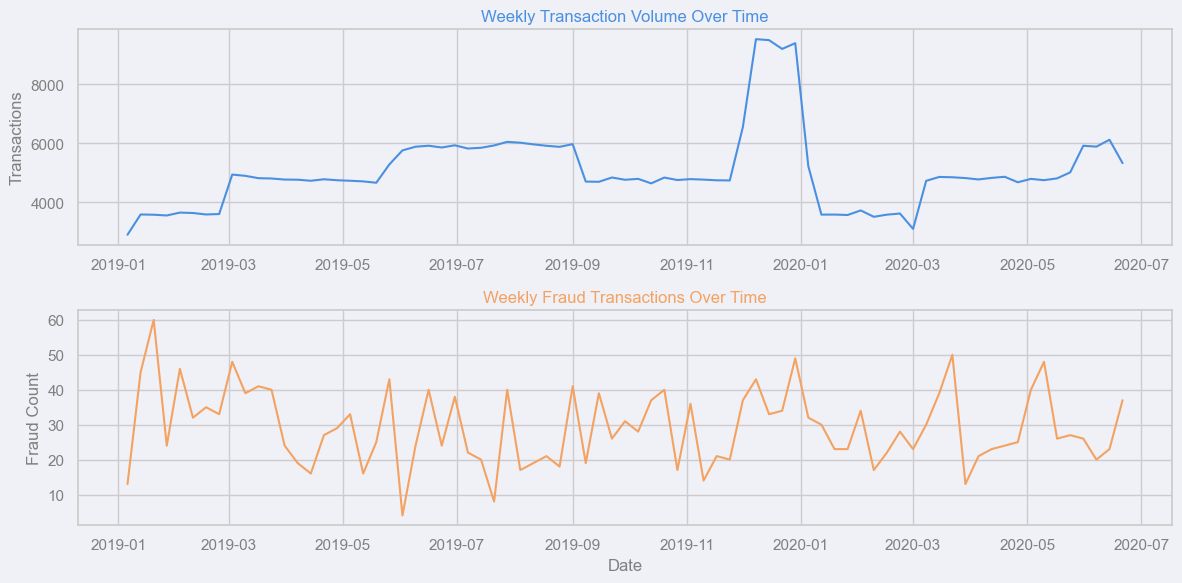

In [10]:
# --- Weekly aggregation ---
weekly_transactions = cc_df.resample('W', on='trans_date_trans_time').size()
weekly_fraud = cc_df.resample('W', on='trans_date_trans_time')['is_fraud'].sum()

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12,6))
fig.patch.set_facecolor('#f0f0f7')

# Transactions
axes[0].plot(weekly_transactions, color='#4A90E2')
axes[0].set_title('Weekly Transaction Volume Over Time', color='#4A90E2')
axes[0].set_ylabel('Transactions', color='gray')
axes[0].tick_params(colors='gray')
axes[0].set_facecolor('#f0f0f7')

# Fraud
axes[1].plot(weekly_fraud, color='#F4A261')
axes[1].set_title('Weekly Fraud Transactions Over Time', color='#F4A261')
axes[1].set_xlabel('Date', color='gray')
axes[1].set_ylabel('Fraud Count', color='gray')
axes[1].tick_params(colors='gray')
axes[1].set_facecolor("#f0f0f7")

plt.tight_layout()
plt.show()

### __10. The target variable distributes across different categories__

C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\1867168773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


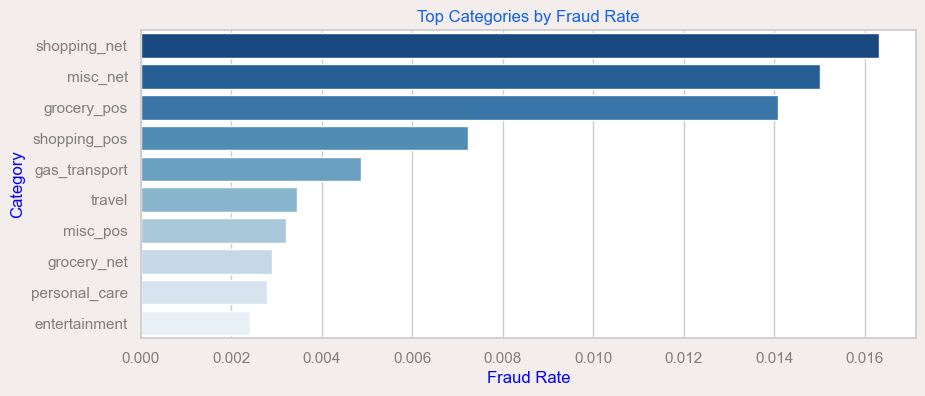

In [11]:
# Fraud rate by category
category_fraud = (
    cc_df.groupby('category')['is_fraud']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10,4))
plt.gcf().patch.set_facecolor("#f3edec")

sns.barplot(
    x=category_fraud.values,
    y=category_fraud.index,
    palette='Blues_r'
)

plt.title('Top Categories by Fraud Rate', color="#1261E9")
plt.xlabel('Fraud Rate', color='blue')
plt.ylabel('Category', color='blue')
plt.xticks(color='gray')
plt.yticks(color='gray')

plt.show()

### __11. Unusual or unexpected values in the dataset that require further investigation__

In [12]:
# --- Check extreme values ---
extreme_amt = cc_df['amt'].max()
extreme_city = cc_df['city_pop'].max()

# --- Check unrealistic ages ---
unusual_age = cc_df[(cc_df['age'] < 18) | (cc_df['age'] > 100)].shape[0]

# --- Check fraud in extreme jobs (very small groups)
job_counts = cc_df['job'].value_counts()
rare_jobs = job_counts[job_counts < 10].index

rare_job_fraud = cc_df[cc_df['job'].isin(rare_jobs)]['is_fraud'].mean()

# --- Print results
print(f"Max transaction amount: {extreme_amt}")
print(f"Max city population: {extreme_city}")
print(f"Unusual age count (<18 or >100): {unusual_age}")
print(f"Fraud rate in rare jobs: {rare_job_fraud:.4f}")

cc_df[['amt','city_pop','age']].describe()

Max transaction amount: 27390.12
Max city population: 2906700
Unusual age count (<18 or >100): 4620
Fraud rate in rare jobs: 1.0000


,amt,city_pop,age
count,389002.00,389002.00,389002.00
mean,70.44,88680.84,45.51
std,162.20,301210.10,17.41
min,1.00,23.00,13.00
25%,9.66,743.00,32.00
50%,47.57,2456.00,43.00
75%,83.08,20328.00,57.00
max,27390.12,2906700.00,95.00


### __12. Potential data entry errors or inconsistencies in the dataset__

In [13]:
# --- Negative or zero values ---
invalid_amt = cc_df[cc_df['amt'] <= 0].shape[0]

# --- Invalid ages (very young or very old)
invalid_age = cc_df[(cc_df['age'] < 18) | (cc_df['age'] > 100)].shape[0]

# --- Missing-like categories (empty strings or unusual labels)
invalid_category = cc_df['category'].isnull().sum()

# --- Check duplicates
duplicates = cc_df.duplicated().sum()

# --- Check inconsistent zip codes (length issue)
invalid_zip = cc_df[cc_df['zip'].astype(str).str.len() != 5].shape[0]

# --- Print results
print(f"Invalid transaction amounts (<=0): {invalid_amt}")
print(f"Invalid age records: {invalid_age}")
print(f"Missing category values: {invalid_category}")
print(f"Duplicate rows: {duplicates}")
print(f"Inconsistent ZIP codes: {invalid_zip}")

Invalid transaction amounts (<=0): 0
Invalid age records: 4620
Missing category values: 0
Duplicate rows: 0
Inconsistent ZIP codes: 24335


* Fixing ZIP CODES

In [14]:
import os

# --- Fix ZIP codes ---
cc_df['zip'] = cc_df['zip'].astype(str).str.extract('(\d+)')[0].str.zfill(5)

# --- Desktop path (auto detect) ---
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")

# --- File path ---
file_path = os.path.join(desktop_path, "cc_data_cleaned.csv")

# --- Save ---
cc_df.to_csv(file_path, index=False)

print(f"File saved to: {file_path}")

# --- Check inconsistent zip codes (length issue)
invalid_zip = cc_df[cc_df['zip'].astype(str).str.len() != 5].shape[0]
print(f"Inconsistent ZIP codes: {invalid_zip}")


File saved to: C:\Users\Nehir\Desktop\cc_data_cleaned.csv
Inconsistent ZIP codes: 0


### __13. The distribution of numerical variables varies between different groups or segments of the dataset__

C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\641944456.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\641944456.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


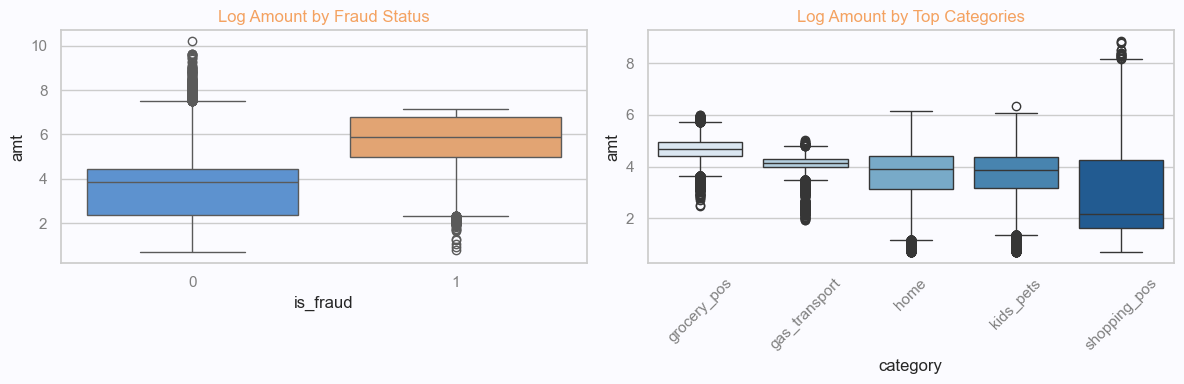

In [15]:
# --- Top 5 categories by transaction count ---
top_categories = cc_df['category'].value_counts().head(5).index

filtered_df = cc_df[cc_df['category'].isin(top_categories)]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12,4))
fig.patch.set_facecolor("#fbfbff")

# 1) Amount vs Fraud (log scale)
sns.boxplot(
    x='is_fraud',
    y=np.log1p(cc_df['amt']),
    data=cc_df,
    palette=['#4A90E2', '#F4A261'],
    ax=axes[0]
)

axes[0].set_title('Log Amount by Fraud Status', color='#F4A261')
axes[0].tick_params(colors='gray')
axes[0].set_facecolor('#fbfbff')

# 2) Amount vs Category
sns.boxplot(
    x='category',
    y=np.log1p(filtered_df['amt']),
    data=filtered_df,
    palette='Blues',
    ax=axes[1]
)

axes[1].set_title('Log Amount by Top Categories', color='#F4A261')
axes[1].tick_params(colors='gray')
axes[1].set_facecolor("#fbfbff")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### __14. The top factors that influence the target variable__

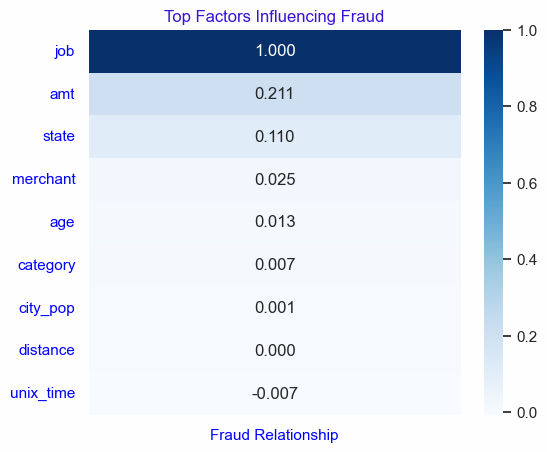

In [16]:
# --- AGE  ---
cc_df['trans_date_trans_time'] = pd.to_datetime(cc_df['trans_date_trans_time'], errors='coerce')
cc_df['dob'] = pd.to_datetime(cc_df['dob'], errors='coerce')

# --- Age ---
cc_df['age'] = (cc_df['trans_date_trans_time'] - cc_df['dob']).dt.days // 365

# --- DISTANCE (customer vs merchant) ---
cc_df['distance'] = np.sqrt(
    (cc_df['lat'] - cc_df['merch_lat'])**2 +
    (cc_df['long'] - cc_df['merch_long'])**2
)

# --- NUMERICAL CORRELATIONS ---
corr_features = {
    'amt': cc_df[['amt', 'is_fraud']].corr().iloc[0,1],
    'age': cc_df[['age', 'is_fraud']].corr().iloc[0,1],
    'city_pop': cc_df[['city_pop', 'is_fraud']].corr().iloc[0,1],
    'distance': cc_df[['distance', 'is_fraud']].corr().iloc[0,1],
    'unix_time': cc_df[['unix_time', 'is_fraud']].corr().iloc[0,1]
}

# --- CATEGORICAL ---
category_score = cc_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(10).mean()
job_score = cc_df.groupby('job')['is_fraud'].mean().sort_values(ascending=False).head(10).mean()
merchant_score = cc_df.groupby('merchant')['is_fraud'].mean().sort_values(ascending=False).head(10).mean()
state_score = cc_df.groupby('state')['is_fraud'].mean().sort_values(ascending=False).head(10).mean()

cat_features = {
    'category': category_score,
    'job': job_score,
    'merchant': merchant_score,
    'state': state_score
}

# --- COMBINE ---
all_features = {**corr_features, **cat_features}

heatmap_df = pd.DataFrame.from_dict(all_features, orient='index', columns=['Fraud Relationship'])
heatmap_df = heatmap_df.sort_values(by='Fraud Relationship', ascending=False)

# --- PLOT ---
plt.figure(figsize=(6,5))
plt.gcf().patch.set_facecolor("#fefeff")

sns.heatmap(
    heatmap_df,
    annot=True,
    cmap='Blues',
    fmt=".3f"
)

plt.title('Top Factors Influencing Fraud', color="#3911D7")
plt.xticks(color='blue')
plt.yticks(color='blue')

plt.show()

## __DASHBOARD__

C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\165910264.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\165910264.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Nehir\AppData\Local\Temp\ipykernel_6712\165910264.py:134: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_df = cc_df.groupby('amt_bin')['is_fraud'].mean().reset_index()


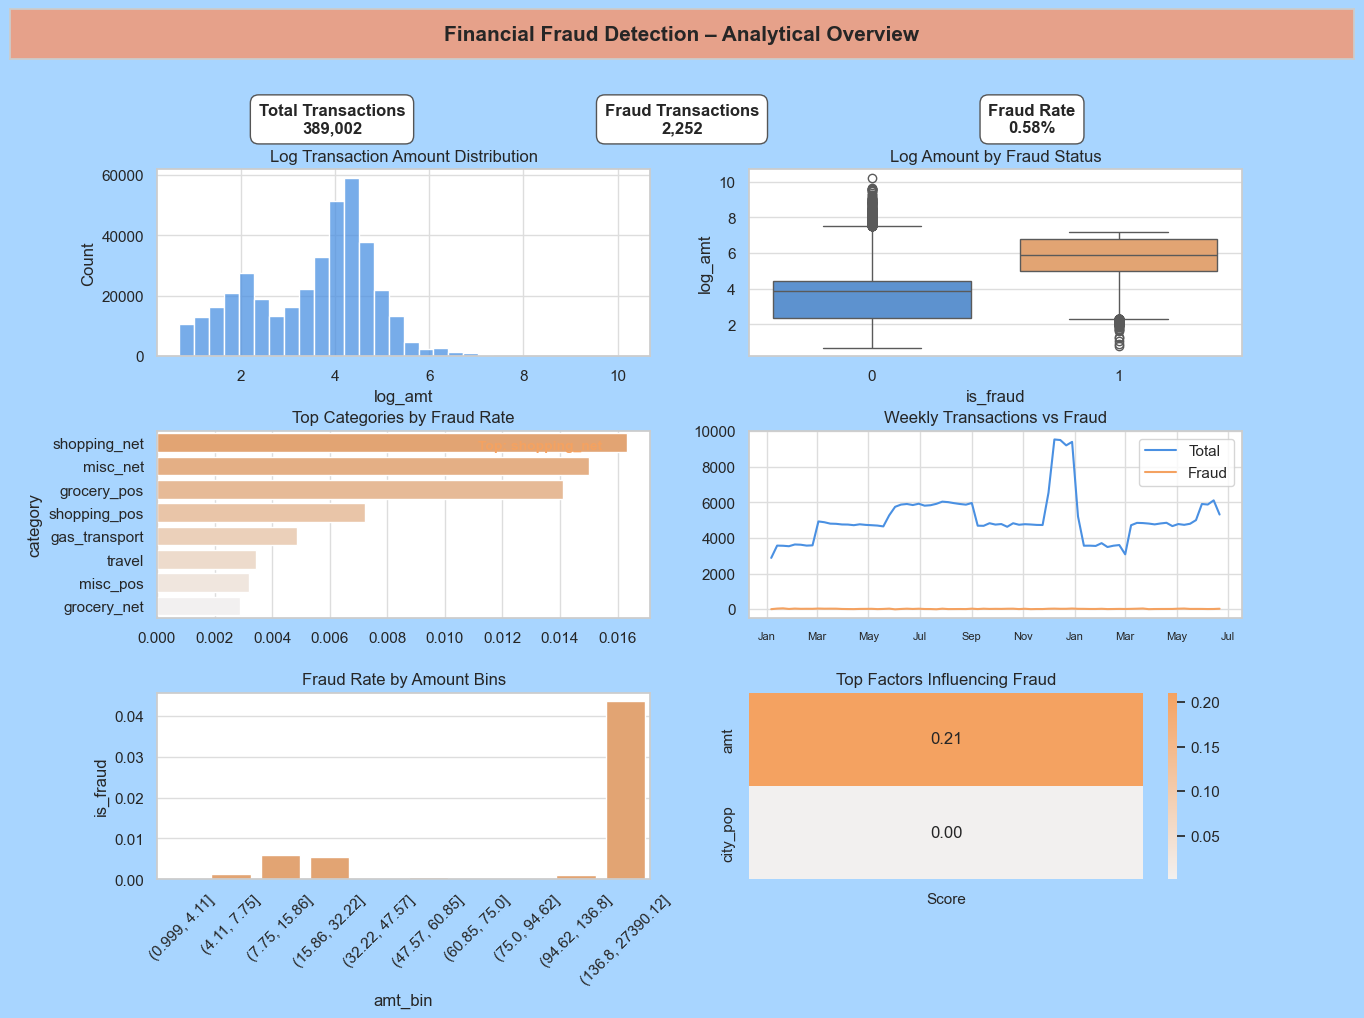

In [17]:
import matplotlib.image as mpimg
sns.set_style("whitegrid")

# ================= DATA =================
cc_df['trans_date_trans_time'] = pd.to_datetime(cc_df['trans_date_trans_time'])
cc_df['log_amt'] = np.log1p(cc_df['amt'])

# ================= COLORS =================
page_bg = "#A8D5FF"
blue = "#4A90E2"
orange = "#F4A261"

# ================= FIGURE =================
fig = plt.figure(figsize=(14,10), facecolor=page_bg)

# ================= HEADER =================
header_ax = fig.add_axes([0.02, 0.93, 0.96, 0.05])
header_ax.set_facecolor("#E6A18A")
header_ax.set_xticks([])
header_ax.set_yticks([])
header_ax.text(
    0.5, 0.5,
    "Financial Fraud Detection – Analytical Overview",
    ha="center", va="center",
    fontsize=15, fontweight="bold"
)

# ================= KPI =================
total_tx = len(cc_df)
fraud_tx = cc_df['is_fraud'].sum()
fraud_rate = fraud_tx / total_tx

def kpi(x, title, value):
    fig.text(
        x, 0.87,
        f"{title}\n{value}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="#555", boxstyle="round,pad=0.5")
    )

kpi(0.25, "Total Transactions", f"{total_tx:,}")
kpi(0.50, "Fraud Transactions", f"{fraud_tx:,}")
kpi(0.75, "Fraud Rate", f"{fraud_rate:.2%}")

# ================= GRID =================
gs = fig.add_gridspec(3, 2, top=0.82, hspace=0.4)

def clean(ax):
    ax.set_facecolor("white")
    ax.grid(True, color="#dddddd")
    for spine in ax.spines.values():
        spine.set_color("#cccccc")

# ================= FORMATTER =================
def dollar(x, pos):
    return f"${x:,.0f}"

# ================= 1. LOG DISTRIBUTION =================
ax1 = fig.add_subplot(gs[0,0])
clean(ax1)

sns.histplot(cc_df['log_amt'], bins=30, color=blue, ax=ax1)
ax1.set_title("Log Transaction Amount Distribution")

# ================= 2. FRAUD VS NON =================
ax2 = fig.add_subplot(gs[0,1])
clean(ax2)

sns.boxplot(
    data=cc_df,
    x='is_fraud',
    y='log_amt',
    palette=[blue, orange],
    ax=ax2
)

ax2.set_title("Log Amount by Fraud Status")

# ================= 3. CATEGORY =================
ax3 = fig.add_subplot(gs[1,0])
clean(ax3)

cat = cc_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(8)

sns.barplot(
    x=cat.values,
    y=cat.index,
    palette=sns.light_palette(orange, n_colors=8, reverse=True),
    ax=ax3
)

ax3.set_title("Top Categories by Fraud Rate")

# KPI annotation
ax3.text(
    0.65, 0.9,
    f"Top: {cat.index[0]}",
    transform=ax3.transAxes,
    color=orange,
    fontsize=10,
    fontweight="bold"
)

# ================= 4. TREND =================
ax4 = fig.add_subplot(gs[1,1])
clean(ax4)

weekly_total = cc_df.resample('W', on='trans_date_trans_time').size()
weekly_fraud = cc_df.resample('W', on='trans_date_trans_time')['is_fraud'].sum()

ax4.plot(weekly_total, color=blue, label="Total")
ax4.plot(weekly_fraud, color=orange, label="Fraud")

ax4.legend()
ax4.set_title("Weekly Transactions vs Fraud")

# fix date overlap
import matplotlib.dates as mdates

ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b'))   # Jan, Feb, Mar
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax4.tick_params(axis='x', labelsize=8)
for label in ax4.get_xticklabels():
    label.set_rotation(0)

# ================= 5. BIN ANALYSIS =================
ax5 = fig.add_subplot(gs[2,0])
clean(ax5)

cc_df['amt_bin'] = pd.qcut(cc_df['amt'], q=10, duplicates='drop')
bin_df = cc_df.groupby('amt_bin')['is_fraud'].mean().reset_index()

sns.barplot(
    x=bin_df['amt_bin'].astype(str),
    y=bin_df['is_fraud'],
    color=orange,
    ax=ax5
)

ax5.tick_params(axis='x', rotation=45)
ax5.set_title("Fraud Rate by Amount Bins")

# ================= 6. TOP FACTORS =================
ax6 = fig.add_subplot(gs[2,1])
clean(ax6)

feat = {
    'amt': cc_df[['amt','is_fraud']].corr().iloc[0,1],
    'city_pop': cc_df[['city_pop','is_fraud']].corr().iloc[0,1]
}

feat_df = pd.DataFrame.from_dict(feat, orient='index', columns=['Score'])

sns.heatmap(
    feat_df,
    annot=True,
    cmap=sns.light_palette(orange, as_cmap=True),
    fmt=".2f",
    ax=ax6
)

ax6.set_title("Top Factors Influencing Fraud")

# ================= SHOW =================
plt.show()

## __CONCLUSION__

In [18]:
import ipywidgets as widgets
from IPython.display import display, HTML


# --- Safety: ensure columns exist ---
cc_df['trans_date_trans_time'] = pd.to_datetime(cc_df['trans_date_trans_time'], errors='coerce')

# --- Button function ---
def generate_insight(b):

    # --- Calculations ---
    fraud_rate = cc_df['is_fraud'].mean()

    amt_corr = cc_df[['amt','is_fraud']].corr().iloc[0,1]

    top_category = cc_df.groupby('category')['is_fraud'].mean().idxmax()
    top_category_rate = cc_df.groupby('category')['is_fraud'].mean().max()

    # --- Bin safely ---
    bins = pd.qcut(cc_df['amt'], q=10, duplicates='drop')
    high_bin = cc_df.groupby(bins)['is_fraud'].mean().idxmax()

    # --- HTML OUTPUT ---
    insight_html = f"""
    <div style="
        background-color:white;
        padding:20px;
        border-radius:12px;
        border-left:8px solid #F4A261;
        font-size:15px;
        line-height:1.7;
        color:#333;
        max-width:900px;
    ">
    
    <h2 style="color:#F4A261; margin-bottom:10px;">🔍 Fraud Analysis Conclusion</h2>
    
    <ul>
        <li><b>Fraud rate</b> remains relatively low at <b>{fraud_rate:.2%}</b>, indicating rare but high-impact events.</li>
        
        <li><b>Transaction amount</b> is the strongest indicator of fraud 
        (correlation = <b>{amt_corr:.2f}</b>).</li>
        
        <li>Highest fraud risk occurs in the <b>{top_category}</b> category 
        (fraud rate ≈ <b>{top_category_rate:.2%}</b>).</li>
        
        <li>Fraud probability increases significantly in high-value transactions 
        (range: <b>{high_bin}</b>).</li>
        
        <li>Temporal patterns suggest <b>periodic spikes</b>, indicating potential behavioral or seasonal effects.</li>
    </ul>

    <p style="margin-top:12px;">
    <b>Recommendation:</b> Fraud detection systems should prioritize high-value transactions, 
    category-level patterns, and time-based anomalies.
    </p>

    </div>
    """

    display(HTML(insight_html))


# --- Button ---
button = widgets.Button(
    description="Generate Final Insight",
    button_style='warning',
    layout=widgets.Layout(width='220px', height='45px')
)

button.on_click(generate_insight)

display(button)

Button(button_style='warning', description='Generate Final Insight', layout=Layout(height='45px', width='220px…